In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 5)

db_path = r'C:\Users\beril.oztan\Desktop\rossmann-demand-forecast\data\processed\rossmann.db'
conn = sqlite3.connect(db_path)

def query(sql):
    return pd.read_sql_query(sql, conn)

print("Bağlantı tamam!")

Bağlantı tamam!


In [8]:
df = query("SELECT * FROM sales_master LIMIT 5")
df

,Store,Date,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2
0,1,2015-07-31,5,5263,555,1,0,1,c,a,1270.0,0
1,2,2015-07-31,5,6064,625,1,0,1,a,a,570.0,1
2,3,2015-07-31,5,8314,821,1,0,1,a,a,14130.0,1
3,4,2015-07-31,5,13995,1498,1,0,1,c,c,620.0,0
4,5,2015-07-31,5,4822,559,1,0,1,a,a,29910.0,0


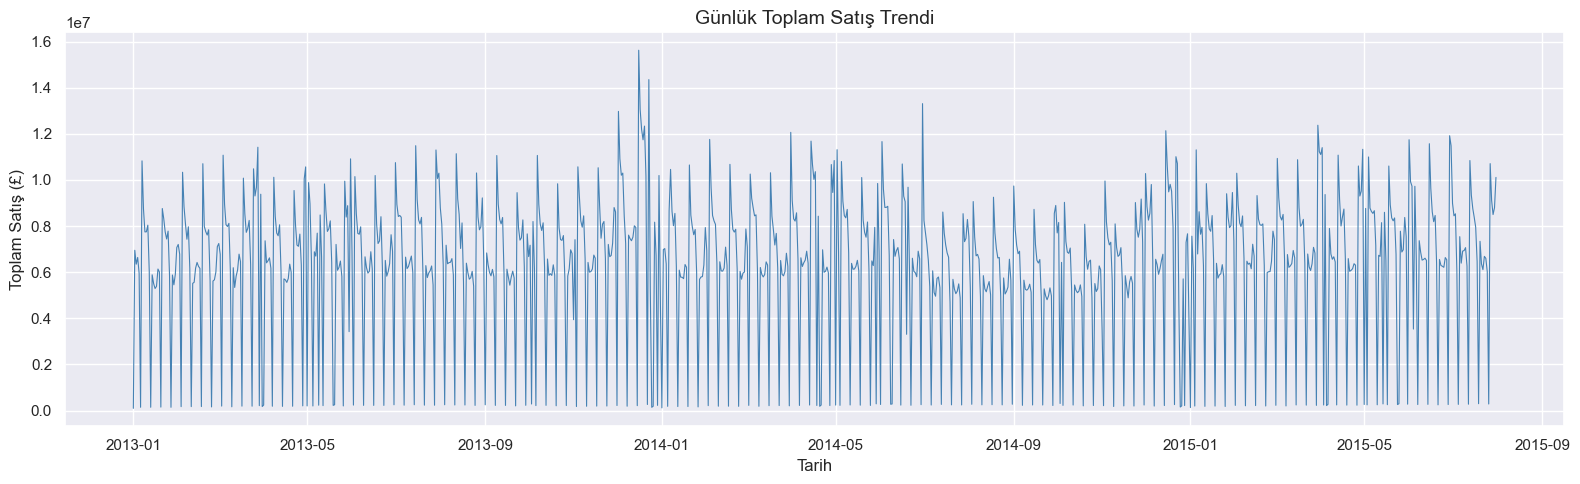

In [9]:
daily = query("""
    SELECT Date, SUM(Sales) as TotalSales
    FROM sales_master
    GROUP BY Date
    ORDER BY Date
""")

daily['Date'] = pd.to_datetime(daily['Date'])

plt.figure(figsize=(16, 5))
plt.plot(daily['Date'], daily['TotalSales'], linewidth=0.8, color='steelblue')
plt.title('Günlük Toplam Satış Trendi', fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış (£)')
plt.tight_layout()
plt.show()

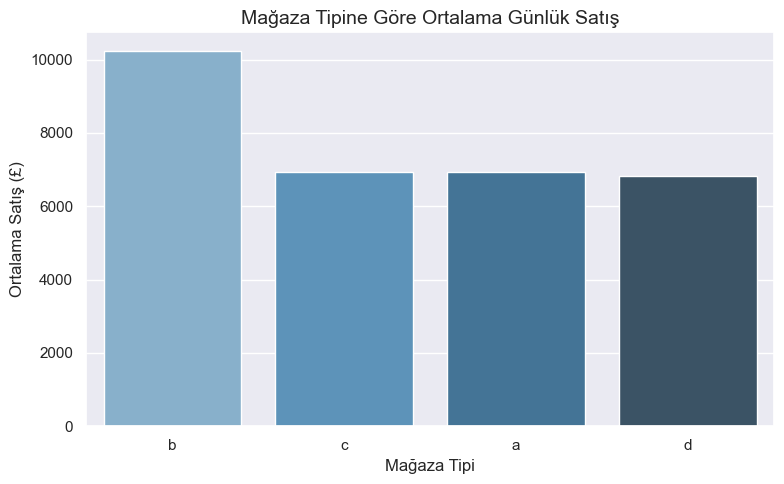

,StoreType,AvgSales,DayCount
0,b,10233.38,15560
1,c,6933.13,112968
2,a,6925.70,457042
3,d,6822.30,258768


In [10]:
store_type = query("""
    SELECT StoreType, ROUND(AVG(Sales), 2) as AvgSales, COUNT(*) as DayCount
    FROM sales_master
    GROUP BY StoreType
    ORDER BY AvgSales DESC
""")

plt.figure(figsize=(8, 5))
sns.barplot(data=store_type, x='StoreType', y='AvgSales', palette='Blues_d')
plt.title('Mağaza Tipine Göre Ortalama Günlük Satış', fontsize=14)
plt.xlabel('Mağaza Tipi')
plt.ylabel('Ortalama Satış (£)')
plt.tight_layout()
plt.show()

store_type

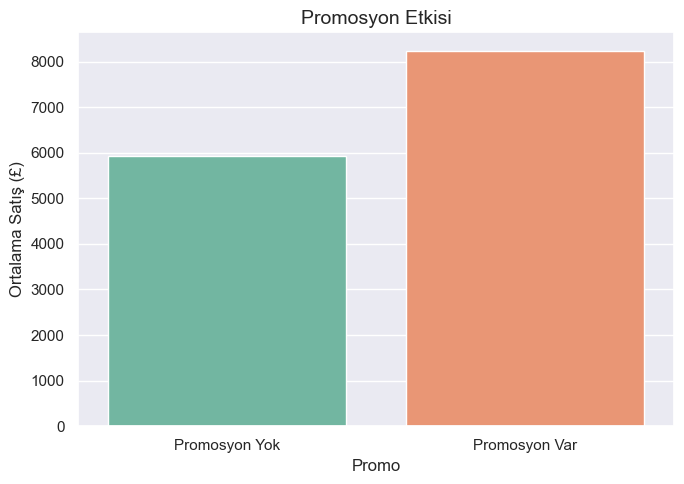

,Promo,AvgSales
0,Promosyon Yok,5929.83
1,Promosyon Var,8228.74


In [11]:
promo = query("""
    SELECT Promo, ROUND(AVG(Sales), 2) as AvgSales
    FROM sales_master
    GROUP BY Promo
""")

promo['Promo'] = promo['Promo'].map({0: 'Promosyon Yok', 1: 'Promosyon Var'})

plt.figure(figsize=(7, 5))
sns.barplot(data=promo, x='Promo', y='AvgSales', palette='Set2')
plt.title('Promosyon Etkisi', fontsize=14)
plt.ylabel('Ortalama Satış (£)')
plt.tight_layout()
plt.show()

promo

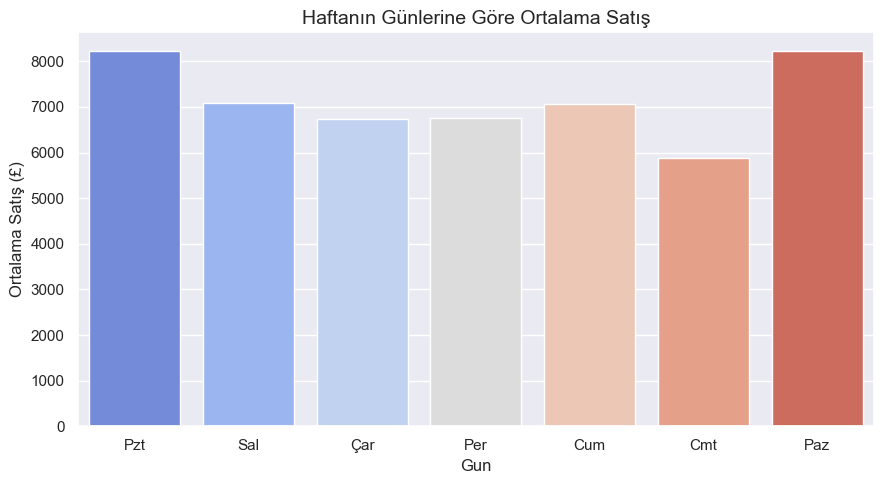

In [12]:
dow = query("""
    SELECT DayOfWeek, ROUND(AVG(Sales), 2) as AvgSales
    FROM sales_master
    GROUP BY DayOfWeek
    ORDER BY DayOfWeek
""")

gun_isimleri = {1:'Pzt', 2:'Sal', 3:'Çar', 4:'Per', 5:'Cum', 6:'Cmt', 7:'Paz'}
dow['Gun'] = dow['DayOfWeek'].map(gun_isimleri)

plt.figure(figsize=(9, 5))
sns.barplot(data=dow, x='Gun', y='AvgSales', palette='coolwarm')
plt.title('Haftanın Günlerine Göre Ortalama Satış', fontsize=14)
plt.ylabel('Ortalama Satış (£)')
plt.tight_layout()
plt.show()

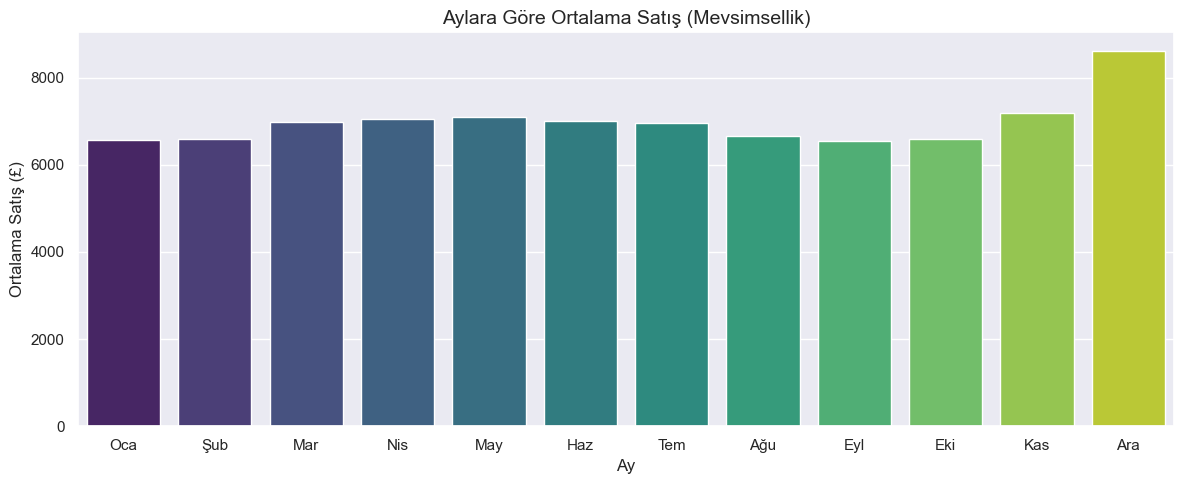

In [13]:
monthly = query("""
    SELECT 
        strftime('%m', Date) as Month,
        ROUND(AVG(Sales), 2) as AvgSales
    FROM sales_master
    GROUP BY Month
    ORDER BY Month
""")

ay_isimleri = {
    '01':'Oca', '02':'Şub', '03':'Mar', '04':'Nis',
    '05':'May', '06':'Haz', '07':'Tem', '08':'Ağu',
    '09':'Eyl', '10':'Eki', '11':'Kas', '12':'Ara'
}
monthly['AyAdi'] = monthly['Month'].map(ay_isimleri)

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly, x='AyAdi', y='AvgSales', palette='viridis')
plt.title('Aylara Göre Ortalama Satış (Mevsimsellik)', fontsize=14)
plt.ylabel('Ortalama Satış (£)')
plt.xlabel('Ay')
plt.tight_layout()
plt.show()

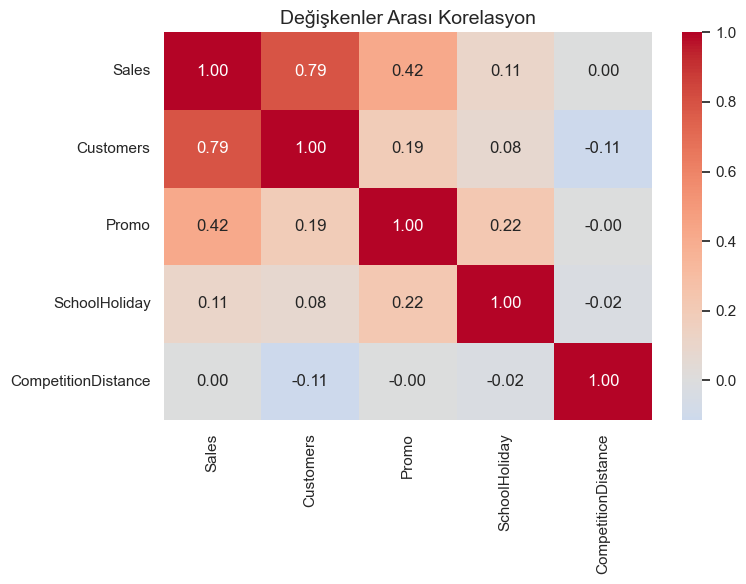

In [14]:
corr_df = query("""
    SELECT 
        Sales,
        Customers,
        Promo,
        SchoolHoliday,
        CompetitionDistance
    FROM sales_master
    LIMIT 50000
""")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Değişkenler Arası Korelasyon', fontsize=14)
plt.tight_layout()
plt.show()